# Hot / Cold Incremental Word Growth from Nibbles

This notebook turns the current idea into an executable substrate model:

- a 32-bit word is not primary,
- it is grown as **8 nibble commits**,
- carry transports upward nibble by nibble,
- the size of the admissible frontier at each step defines **heat**,
- a unique continuation defines **cold / lock**.

This is a generic modular-addition runtime model. It is **not** a cryptographic inverse notebook.

## Core equations

Write any 32-bit word as

\[
X = \sum_{j=0}^{7} 16^j x_j, \qquad x_j \in \{0,\dots,15\}
\]

with \(x_0\) the low nibble.

For a local target equation

\[
T \equiv S + X \pmod{2^{32}},
\]

the nibble-level recurrence is

\[
s_j + x_j + c_j = t_j + 16 c_{j+1},
\]

so the local grow rule is

\[
x_j \equiv t_j - s_j - c_j \pmod{16},
\qquad
c_{j+1} = \left\lfloor \frac{s_j + x_j + c_j}{16} \right\rfloor.
\]

For two unknown channels,

\[
T \equiv S + X + Y \pmod{2^{32}},
\]

the local admissible set is

\[
\mathcal A_j =
\left\{
(x_j, y_j, c_{j+1}) :
s_j + x_j + y_j + c_j = t_j + 16 c_{j+1}
\right\}.
\]

Define local heat as

\[
H_j = \log_2 |\mathcal A_j|,
\]

and lock strength as

\[
L_j = \frac{1}{|\mathcal A_j|}.
\]

So:

- \(H_j = 0\) means cold / unique continuation,
- larger \(H_j\) means hot / branching frontier.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from math import log2
from typing import List, Optional, Tuple

NIBBLES_PER_WORD = 8
NIBBLE_MASK = 0xF
WORD_MASK = 0xFFFFFFFF

@dataclass
class StepResult:
    nibble_index: int
    carry_in: int
    admissible_count: int
    heat_bits: float
    lock_strength: float
    chosen: Optional[Tuple[int, ...]]
    carry_out: Optional[int]
    admissible_examples: List[Tuple[int, ...]]

def nibble(word: int, j: int) -> int:
    return (word >> (4 * j)) & NIBBLE_MASK

def assemble_word(nibbles: List[int]) -> int:
    out = 0
    for j, x in enumerate(nibbles):
        out |= (x & NIBBLE_MASK) << (4 * j)
    return out & WORD_MASK

def heat_from_count(count: int) -> float:
    return log2(count)

def lock_strength_from_count(count: int) -> float:
    return 1.0 / count

def summarize_steps(steps: List[StepResult]):
    return {
        "frontier_sizes": [s.admissible_count for s in steps],
        "heat_bits": [s.heat_bits for s in steps],
        "lock_strengths": [s.lock_strength for s in steps],
        "chosen_path": [list(s.chosen) if s.chosen is not None else None for s in steps],
        "carry_path": [s.carry_out for s in steps],
    }

## 1) Single-unknown cold growth

If the local equation has only one unknown channel,

\[
T \equiv S + X \pmod{2^{32}},
\]

then each nibble is uniquely determined once the carry-in is known.

In [2]:
def single_unknown_step(target_word: int, known_sum_word: int, nibble_index: int, carry_in: int) -> StepResult:
    t_j = nibble(target_word, nibble_index)
    s_j = nibble(known_sum_word, nibble_index)

    x_j = (t_j - s_j - carry_in) % 16
    total = s_j + x_j + carry_in
    carry_out = total // 16

    return StepResult(
        nibble_index=nibble_index,
        carry_in=carry_in,
        admissible_count=1,
        heat_bits=0.0,
        lock_strength=1.0,
        chosen=(x_j,),
        carry_out=carry_out,
        admissible_examples=[(x_j,)],
    )

def grow_single_unknown_word(target_word: int, known_sum_word: int, carry_in0: int = 0):
    out_nibbles = []
    steps = []
    carry = carry_in0

    for j in range(NIBBLES_PER_WORD):
        step = single_unknown_step(target_word, known_sum_word, j, carry)
        out_nibbles.append(step.chosen[0])
        steps.append(step)
        carry = step.carry_out

    return assemble_word(out_nibbles), steps

target = 0x89ABCDEF
known_sum = 0x13579BDF

x_word, cold_steps = grow_single_unknown_word(target, known_sum)
single_result = {
    "target_word_hex": hex(target),
    "known_sum_hex": hex(known_sum),
    "recovered_word_hex": hex(x_word),
    **summarize_steps(cold_steps),
}
single_result

{'target_word_hex': '0x89abcdef',
 'known_sum_hex': '0x13579bdf',
 'recovered_word_hex': '0x76543210',
 'frontier_sizes': [1, 1, 1, 1, 1, 1, 1, 1],
 'heat_bits': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'lock_strengths': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
 'chosen_path': [[0], [1], [2], [3], [4], [5], [6], [7]],
 'carry_path': [0, 0, 0, 0, 0, 0, 0, 0]}

That is the cold regime:

- every nibble has exactly one admissible continuation,
- heat is zero at every step,
- the word crystallizes upward from the low nibble.

## 2) Two-unknown hot frontier

If the local equation has two unknown channels,

\[
T \equiv S + X + Y \pmod{2^{32}},
\]

the frontier opens. A single nibble target does not identify one continuation by itself.

In [3]:
def two_unknown_step(target_word: int, known_sum_word: int, nibble_index: int, carry_in: int) -> StepResult:
    t_j = nibble(target_word, nibble_index)
    s_j = nibble(known_sum_word, nibble_index)

    admissible = []
    for x_j in range(16):
        for y_j in range(16):
            total = s_j + x_j + y_j + carry_in
            if (total & 0xF) == t_j:
                admissible.append((x_j, y_j, total // 16))

    chosen = admissible[0]
    return StepResult(
        nibble_index=nibble_index,
        carry_in=carry_in,
        admissible_count=len(admissible),
        heat_bits=heat_from_count(len(admissible)),
        lock_strength=lock_strength_from_count(len(admissible)),
        chosen=chosen,
        carry_out=chosen[2],
        admissible_examples=admissible[:8],
    )

def grow_two_unknown_frontier(target_word: int, known_sum_word: int, carry_in0: int = 0):
    steps = []
    carry = carry_in0
    for j in range(NIBBLES_PER_WORD):
        step = two_unknown_step(target_word, known_sum_word, j, carry)
        steps.append(step)
        carry = step.carry_out
    return steps

hot_steps = grow_two_unknown_frontier(target, known_sum)
two_result = {
    "target_word_hex": hex(target),
    "known_sum_hex": hex(known_sum),
    **summarize_steps(hot_steps),
}
two_result

{'target_word_hex': '0x89abcdef',
 'known_sum_hex': '0x13579bdf',
 'frontier_sizes': [16, 16, 16, 16, 16, 16, 16, 16],
 'heat_bits': [4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0],
 'lock_strengths': [0.0625,
  0.0625,
  0.0625,
  0.0625,
  0.0625,
  0.0625,
  0.0625,
  0.0625],
 'chosen_path': [[0, 0, 0],
  [0, 1, 0],
  [0, 2, 0],
  [0, 3, 0],
  [0, 4, 0],
  [0, 5, 0],
  [0, 6, 0],
  [0, 7, 0]],
 'carry_path': [0, 0, 0, 0, 0, 0, 0, 0]}

This is the hot regime:

- each nibble has 16 admissible continuations,
- heat is 4 bits per nibble,
- local information is insufficient to lock a single path.

## 3) Cooling by an additional channel

A hot frontier cools when another channel contributes structure.

Here is the simplest version: fix a selector word \(Y\), then solve

\[
T \equiv S + X + Y \pmod{2^{32}}.
\]

Once \(Y\) is provided, the formerly hot two-channel frontier collapses into a cold one-channel path for \(X\).

In [4]:
def grow_with_selector(target_word: int, known_sum_word: int, selector_word: int, carry_in0: int = 0):
    x_nibbles = []
    y_nibbles = []
    steps = []
    carry = carry_in0

    for j in range(NIBBLES_PER_WORD):
        t_j = nibble(target_word, j)
        s_j = nibble(known_sum_word, j)
        y_j = nibble(selector_word, j)

        x_j = (t_j - s_j - y_j - carry) % 16
        total = s_j + x_j + y_j + carry
        carry_out = total // 16

        step = StepResult(
            nibble_index=j,
            carry_in=carry,
            admissible_count=1,
            heat_bits=0.0,
            lock_strength=1.0,
            chosen=(x_j, y_j, carry_out),
            carry_out=carry_out,
            admissible_examples=[(x_j, y_j, carry_out)],
        )
        steps.append(step)
        x_nibbles.append(x_j)
        y_nibbles.append(y_j)
        carry = carry_out

    return assemble_word(x_nibbles), assemble_word(y_nibbles), steps

selector = 0x11111111
x_sel, y_sel, cooled_steps = grow_with_selector(target, known_sum, selector)

cooling_result = {
    "selector_word_hex": hex(selector),
    "frontier_sizes_after_cooling": [s.admissible_count for s in cooled_steps],
    "heat_bits_after_cooling": [s.heat_bits for s in cooled_steps],
    "x_word_hex": hex(x_sel),
    "y_word_hex": hex(y_sel),
}
cooling_result

{'selector_word_hex': '0x11111111',
 'frontier_sizes_after_cooling': [1, 1, 1, 1, 1, 1, 1, 1],
 'heat_bits_after_cooling': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
 'x_word_hex': '0x654320ff',
 'y_word_hex': '0x11111111'}

This is the important runtime picture:

- **hot** means the current local frontier is wide,
- **cold** means a lawful continuation has become unique,
- **cooling** happens when additional structure from another channel shrinks the frontier.

In your language:

\[
	ext{one thing's shape channel} 	o 	ext{another thing's value / selector channel}
\]

and that extra channel collapses the hot frontier into a committed path.

## 4) A simple heat plot

The plot below makes the distinction visible in one glance.

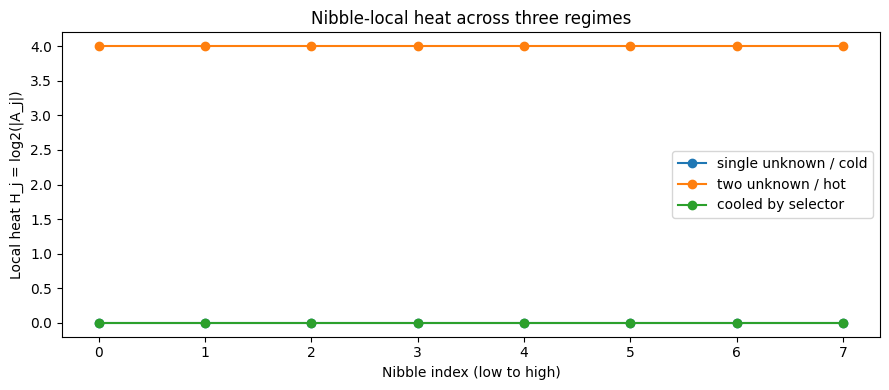

In [5]:
import matplotlib.pyplot as plt

x = list(range(8))
cold_heat = [s.heat_bits for s in cold_steps]
hot_heat = [s.heat_bits for s in hot_steps]
cool_heat = [s.heat_bits for s in cooled_steps]

plt.figure(figsize=(9, 4))
plt.plot(x, cold_heat, marker='o', label='single unknown / cold')
plt.plot(x, hot_heat, marker='o', label='two unknown / hot')
plt.plot(x, cool_heat, marker='o', label='cooled by selector')
plt.xticks(x)
plt.xlabel('Nibble index (low to high)')
plt.ylabel('Local heat H_j = log2(|A_j|)')
plt.title('Nibble-local heat across three regimes')
plt.legend()
plt.tight_layout()
plt.show()

## 5) Compression

The notebook reduces to four statements:

1. A word is an 8-stage nibble compile.
2. Carry is the transport channel between stages.
3. Heat is the size of the local admissible frontier.
4. Cooling is what happens when extra structure collapses that frontier into a unique continuation.

So the executable law is:

\[
oxed{
H_j = \log_2 |\mathcal A_j|
}
\]

with:

- \(H_j = 0\) = cold / locked,
- larger \(H_j\) = hot / branching.

That is the generic substrate notebook for the hot/cold increment system.